In [48]:
### Setup and data loading

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import average_precision_score, precision_recall_curve
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from xgboost import XGBClassifier


In [25]:
# --- FILE PATHS (update for Colab / local) ---
pde_path = r"C:\Users\kaust\Downloads\Hackathon DS & AI\DE1_0_2008_to_2010_Prescription_Drug_Events_Sample_1.csv"
bene_path = r"C:\Users\kaust\Downloads\Hackathon DS & AI\DE1_0_2010_Beneficiary_Summary_File_Sample_1.csv"

# --- LOAD DATA ---
pde = pd.read_csv(pde_path, low_memory=False)
bene = pd.read_csv(bene_path)

print("PDE shape:", pde.shape)
print("Bene shape:", bene.shape)


PDE shape: (5552421, 8)
Bene shape: (112754, 32)


In [26]:
pde.head(), pde.info()
bene.head(), bene.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5552421 entries, 0 to 5552420
Data columns (total 8 columns):
 #   Column          Dtype  
---  ------          -----  
 0   DESYNPUF_ID     object 
 1   PDE_ID          int64  
 2   SRVC_DT         int64  
 3   PROD_SRVC_ID    object 
 4   QTY_DSPNSD_NUM  float64
 5   DAYS_SUPLY_NUM  int64  
 6   PTNT_PAY_AMT    float64
 7   TOT_RX_CST_AMT  float64
dtypes: float64(3), int64(3), object(2)
memory usage: 338.9+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112754 entries, 0 to 112753
Data columns (total 32 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   DESYNPUF_ID               112754 non-null  object 
 1   BENE_BIRTH_DT             112754 non-null  int64  
 2   BENE_DEATH_DT             1863 non-null    float64
 3   BENE_SEX_IDENT_CD         112754 non-null  int64  
 4   BENE_RACE_CD              112754 non-null  int64  
 5   BENE_ESRD_IND             

(        DESYNPUF_ID  BENE_BIRTH_DT  BENE_DEATH_DT  BENE_SEX_IDENT_CD  \
 0  00013D2EFD8E45D1       19230501            NaN                  1   
 1  00016F745862898F       19430101            NaN                  1   
 2  0001FDD721E223DC       19360901            NaN                  2   
 3  00021CA6FF03E670       19410601            NaN                  1   
 4  00024B3D2352D2D0       19360801            NaN                  1   
 
    BENE_RACE_CD BENE_ESRD_IND  SP_STATE_CODE  BENE_COUNTY_CD  \
 0             1             0             26             950   
 1             1             Y             39             230   
 2             1             0             39             280   
 3             5             0              6             290   
 4             1             0             52             590   
 
    BENE_HI_CVRAGE_TOT_MONS  BENE_SMI_CVRAGE_TOT_MONS  ...  SP_STRKETIA  \
 0                       12                        12  ...            2   
 1                

In [ ]:
### Basic cleaning and merge

In [27]:
pde["DESYNPUF_ID"] = pde["DESYNPUF_ID"].astype(str)
bene["DESYNPUF_ID"] = bene["DESYNPUF_ID"].astype(str)

pde["PROD_SRVC_ID"] = pde["PROD_SRVC_ID"].astype(str)

pde["SRVC_DT"] = pd.to_datetime(pde["SRVC_DT"].astype(str), format="%Y%m%d")

bene["BENE_BIRTH_DT"] = pd.to_datetime(bene["BENE_BIRTH_DT"].astype(str), format="%Y%m%d", errors="coerce")
bene["BENE_DEATH_DT"] = pd.to_datetime(bene["BENE_DEATH_DT"].astype("Int64").astype(str), format="%Y%m%d", errors="coerce")


In [28]:
df = pde.merge(bene, on="DESYNPUF_ID", how="left")
df.shape


(5552421, 39)

In [49]:
### 3. Label: late refill for patient–drug pairs

In [31]:
GRACE_DAYS = 7

df = df.sort_values(["DESYNPUF_ID", "PROD_SRVC_ID", "SRVC_DT"])

df["next_SRVC_DT"] = df.groupby(["DESYNPUF_ID", "PROD_SRVC_ID"])["SRVC_DT"].shift(-1)
df["expected_runout"] = df["SRVC_DT"] + pd.to_timedelta(df["DAYS_SUPLY_NUM"], unit="D")

df["late_refill"] = np.where(
    df["next_SRVC_DT"].notna() &
    (df["next_SRVC_DT"] > df["expected_runout"] + pd.to_timedelta(GRACE_DAYS, unit="D")),
    1,
    0
)

df_labeled = df[df["next_SRVC_DT"].notna()].copy()
df_labeled["late_refill"].value_counts(normalize=True)


late_refill
1    0.913456
0    0.086544
Name: proportion, dtype: float64

In [ ]:
### 4. First‑pass feature engineering

In [ ]:
#### 4.1 Beneficiary features (demographics + chronic conditions)

In [32]:
df_labeled["age_years"] = (df_labeled["SRVC_DT"] - df_labeled["BENE_BIRTH_DT"]).dt.days / 365.25

demo_cols = ["age_years", "BENE_SEX_IDENT_CD", "BENE_RACE_CD"]


In [33]:
chronic_cols = [c for c in df_labeled.columns if c.startswith("SP_")]


In [ ]:
### 4.2 Refill behavior features (per patient–drug)

In [34]:
g = df_labeled.groupby(["DESYNPUF_ID", "PROD_SRVC_ID"])

df_labeled["n_prior_fills"] = g.cumcount()

df_labeled["prev_SRVC_DT"] = g["SRVC_DT"].shift(1)
df_labeled["gap_prev"] = (df_labeled["SRVC_DT"] - df_labeled["prev_SRVC_DT"]).dt.days

df_labeled["avg_gap_hist"] = (
    g["gap_prev"]
    .apply(lambda s: s.shift(1).expanding().mean())
    .reset_index(level=[0,1], drop=True)
)

df_labeled["gap_prev"] = df_labeled["gap_prev"].fillna(df_labeled["gap_prev"].median())
df_labeled["avg_gap_hist"] = df_labeled["avg_gap_hist"].fillna(df_labeled["gap_prev"].median())


In [ ]:
### 4.3 Cost/quantity features

In [35]:
cost_cols = ["QTY_DSPNSD_NUM", "DAYS_SUPLY_NUM", "PTNT_PAY_AMT", "TOT_RX_CST_AMT"]


In [ ]:
### 4.4 Simple polypharmacy proxy

In [36]:
df_labeled["n_distinct_drugs_patient"] = (
    df_labeled.groupby("DESYNPUF_ID")["PROD_SRVC_ID"]
    .transform(lambda s: s.expanding().apply(lambda x: len(set(x)), raw=False))
)


In [ ]:
### Final feature set

In [37]:
feature_cols = (
    demo_cols
    + chronic_cols
    + cost_cols
    + ["n_prior_fills", "gap_prev", "avg_gap_hist", "n_distinct_drugs_patient"]
)

X = df_labeled[feature_cols].fillna(0)
y = df_labeled["late_refill"].astype(int)


In [ ]:
### 5. Time‑based train/validation split

In [38]:
cutoff = pd.to_datetime("2009-12-31")

train_mask = df_labeled["SRVC_DT"] <= cutoff
test_mask = df_labeled["SRVC_DT"] > cutoff

X_train, y_train = X[train_mask], y[train_mask]
X_test, y_test = X[test_mask], y[test_mask]


In [ ]:
6. Baseline models + PR‑AUC

In [ ]:
### 6.1 Logistic Regression (baseline)

In [39]:
log_reg = Pipeline([
    ("scaler", StandardScaler(with_mean=False)),
    ("clf", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

log_reg.fit(X_train, y_train)
y_pred_lr = log_reg.predict_proba(X_test)[:, 1]

pr_auc_lr = average_precision_score(y_test, y_pred_lr)
pr_auc_lr


np.float64(0.7490073109346929)

In [ ]:
### 6.2 XGBoost

In [40]:
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=(y_train.value_counts()[0] / y_train.value_counts()[1])
)

xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict_proba(X_test)[:, 1]

pr_auc_xgb = average_precision_score(y_test, y_pred_xgb)
pr_auc_xgb


np.float64(0.7532889295450085)

In [ ]:
### Precision–Recall Curve

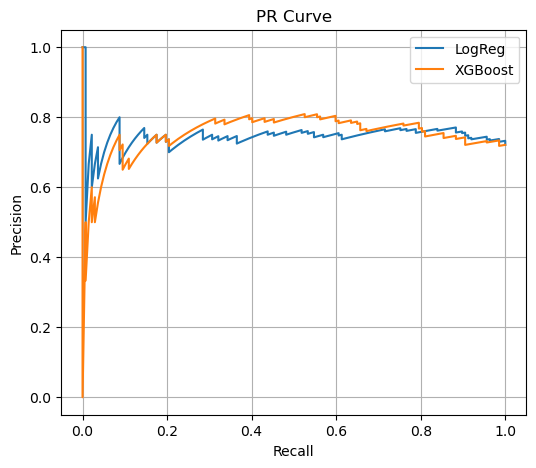

In [41]:
def plot_pr(y_true, y_scores, label):
    p, r, _ = precision_recall_curve(y_true, y_scores)
    plt.plot(r, p, label=label)

plt.figure(figsize=(6,5))
plot_pr(y_test, y_pred_lr, "LogReg")
plot_pr(y_test, y_pred_xgb, "XGBoost")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("PR Curve")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
### 10. Patient Timeline Visualization

In [43]:
df_labeled["risk_xgb"] = np.nan
df_labeled.loc[test_mask, "risk_xgb"] = y_pred_xgb

candidate = df_labeled.loc[
    test_mask & (df_labeled["late_refill"] == 1)
].groupby(["DESYNPUF_ID", "PROD_SRVC_ID"]).head(1).iloc[0]

pid = candidate["DESYNPUF_ID"]
drug = candidate["PROD_SRVC_ID"]
pid, drug


('03454F69D9CA7ADF', '52555046005')

In [44]:
timeline = df_labeled[
    (df_labeled["DESYNPUF_ID"] == pid) &
    (df_labeled["PROD_SRVC_ID"] == drug)
].sort_values("SRVC_DT")

timeline[["SRVC_DT", "DAYS_SUPLY_NUM", "late_refill", "risk_xgb"]]


,SRVC_DT,DAYS_SUPLY_NUM,late_refill,risk_xgb
70272,2010-11-01,30,1,0.827651


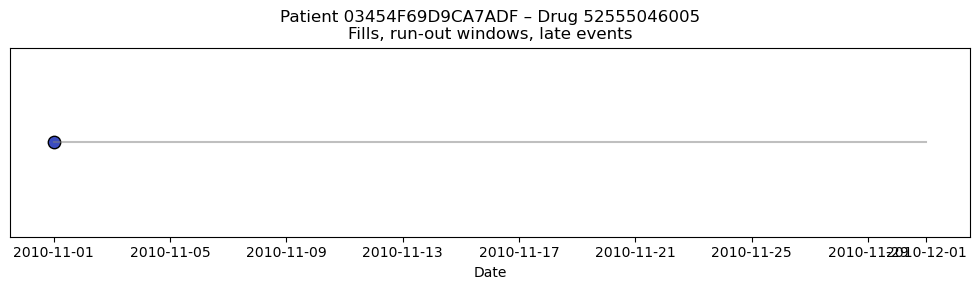

In [45]:
plt.figure(figsize=(10,3))

plt.scatter(timeline["SRVC_DT"], [1]*len(timeline),
            c=timeline["late_refill"], cmap="coolwarm", s=80, edgecolor="k")

for _, row in timeline.iterrows():
    runout = row["expected_runout"]
    plt.plot([row["SRVC_DT"], runout], [1,1], color="gray", alpha=0.5)

plt.yticks([])
plt.title(f"Patient {pid} – Drug {drug}\nFills, run-out windows, late events")
plt.xlabel("Date")
plt.tight_layout()
plt.show()


In [46]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix
)

def evaluate_model(name, y_true, y_pred_proba, threshold=0.5):
    y_pred = (y_pred_proba >= threshold).astype(int)
    
    print(f"\n===== {name} =====")
    print(f"PR-AUC:        {average_precision_score(y_true, y_pred_proba):.4f}")
    print(f"ROC-AUC:       {roc_auc_score(y_true, y_pred_proba):.4f}")
    print(f"Accuracy:      {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision:     {precision_score(y_true, y_pred):.4f}")
    print(f"Recall:        {recall_score(y_true, y_pred):.4f}")
    print(f"F1 Score:      {f1_score(y_true, y_pred):.4f}")
    
    cm = confusion_matrix(y_true, y_pred)
    print("\nConfusion Matrix:")
    print(cm)
    print("-----------------------------")

# Evaluate both models
evaluate_model("Logistic Regression", y_test, y_pred_lr)
evaluate_model("XGBoost", y_test, y_pred_xgb)



===== Logistic Regression =====
PR-AUC:        0.7490
ROC-AUC:       0.5698
Accuracy:      0.6947
Precision:     0.7616
Recall:        0.8394
F1 Score:      0.7986

Confusion Matrix:
[[ 17  36]
 [ 22 115]]
-----------------------------

===== XGBoost =====
PR-AUC:        0.7533
ROC-AUC:       0.5973
Accuracy:      0.6632
Precision:     0.7450
Recall:        0.8102
F1 Score:      0.7762

Confusion Matrix:
[[ 15  38]
 [ 26 111]]
-----------------------------


In [50]:
importance = xgb.feature_importances_
feat_imp = pd.DataFrame({
    "feature": feature_cols,
    "importance": importance
}).sort_values("importance", ascending=False)

feat_imp.head(20)


,feature,importance
16,DAYS_SUPLY_NUM,0.141140
12,SP_OSTEOPRS,0.057616
8,SP_COPD,0.054143
13,SP_RA_OA,0.052707
4,SP_ALZHDMTA,0.051553
14,SP_STRKETIA,0.050910
6,SP_CHRNKIDN,0.047740
15,QTY_DSPNSD_NUM,0.047535
0,age_years,0.047067
7,SP_CNCR,0.046106


In [51]:
!pip install shap


   ---------------------------------------- 0.0/555.9 kB ? eta -:--:--
   --------------------------------------- 555.9/555.9 kB 16.1 MB/s eta 0:00:00

   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   ---------------------------------------- 2/2 [shap]



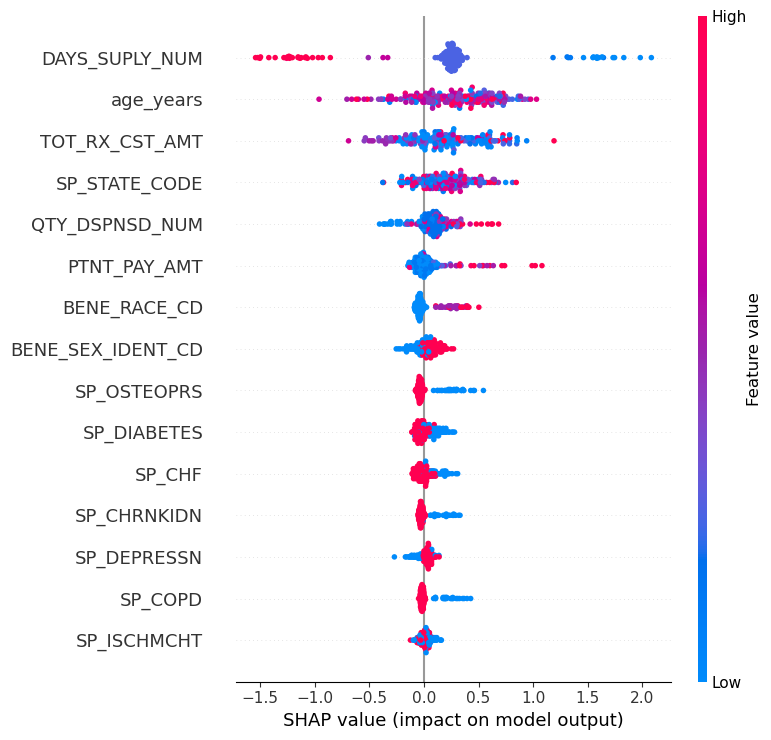

In [52]:
import shap
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, max_display=15)


In [58]:
import shap
shap.initjs()


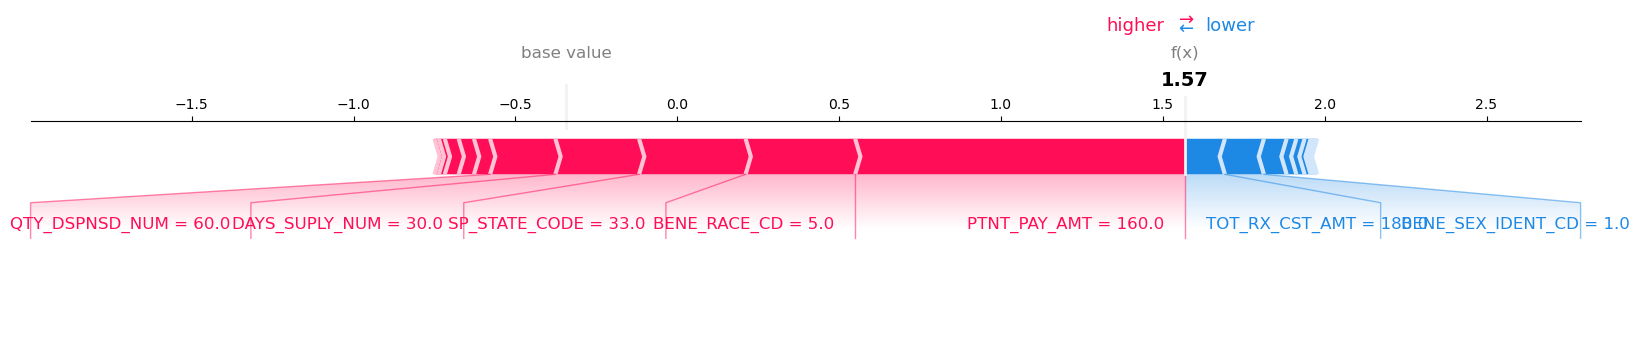

In [59]:
shap.plots.force(
    explainer.expected_value,
    shap_values[local_idx],
    X_test.iloc[local_idx],
    matplotlib=True
)


In [61]:
explainer = shap.TreeExplainer(xgb)
shap_exp = explainer(X_test)   # This returns an Explanation object


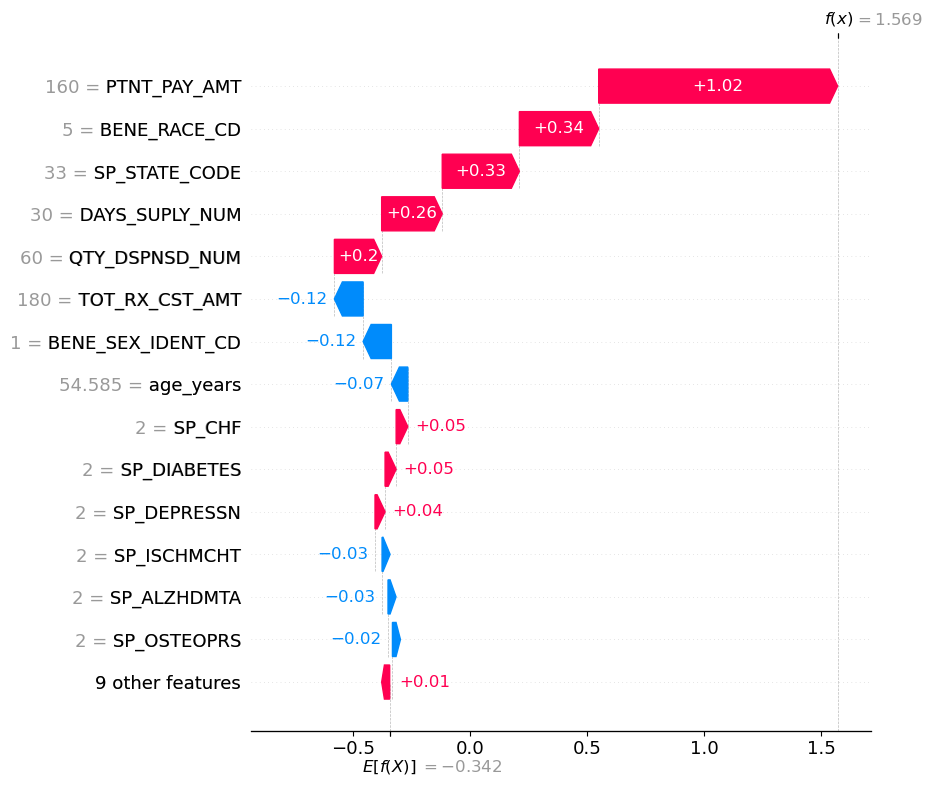

In [63]:
shap.plots.waterfall(
    shap_exp[local_idx],
    max_display=15
)


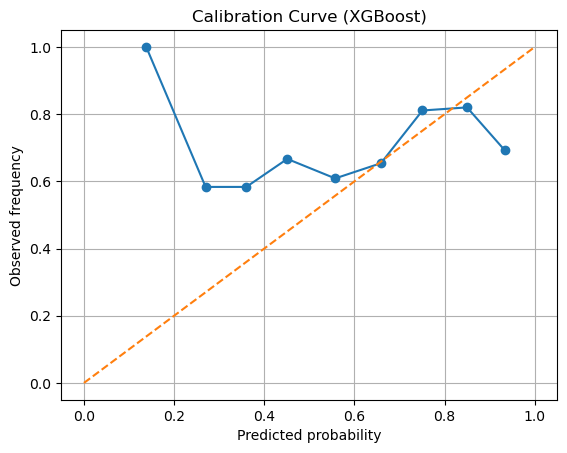

In [54]:
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(y_test, y_pred_xgb, n_bins=10)

plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0,1],[0,1], '--')
plt.xlabel("Predicted probability")
plt.ylabel("Observed frequency")
plt.title("Calibration Curve (XGBoost)")
plt.grid(True)
plt.show()


In [64]:
df_labeled["gap_var_3"] = (
    df_labeled.groupby(["DESYNPUF_ID", "PROD_SRVC_ID"])["gap_prev"]
    .rolling(3)
    .std()
    .reset_index(level=[0,1], drop=True)
)

df_labeled["gap_var_3"] = df_labeled["gap_var_3"].fillna(0)


In [65]:
df_labeled["adherence_score"] = (
    df_labeled["DAYS_SUPLY_NUM"] / df_labeled["gap_prev"].replace(0, 1)
).clip(0, 1)


In [66]:
df_labeled["early_refill"] = (df_labeled["gap_prev"] < df_labeled["DAYS_SUPLY_NUM"]).astype(int)


In [69]:
df_labeled["drug_class"] = df_labeled["PROD_SRVC_ID"].str[:5]


In [70]:
df_labeled["drug_class_freq"] = (
    df_labeled.groupby(["DESYNPUF_ID", "drug_class"])["SRVC_DT"]
    .transform("count")
)

In [71]:
df_labeled["poly_90d"] = (
    df_labeled.groupby("DESYNPUF_ID")["PROD_SRVC_ID"]
    .transform(lambda s: s.rolling(90, min_periods=1).apply(lambda x: len(set(x)), raw=False))
)


In [72]:
df_labeled["patient_gap_mean"] = (
    df_labeled.groupby("DESYNPUF_ID")["gap_prev"].transform("mean")
)
df_labeled["patient_gap_std"] = (
    df_labeled.groupby("DESYNPUF_ID")["gap_prev"].transform("std").fillna(0)
)


In [73]:
xgb_tuned = XGBClassifier(
    n_estimators=400,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    min_child_weight=3,
    gamma=0.1,
    scale_pos_weight=(y_train.value_counts()[0] / y_train.value_counts()[1]),
    eval_metric="logloss"
)

xgb_tuned.fit(X_train, y_train)
y_pred_xgb_tuned = xgb_tuned.predict_proba(X_test)[:, 1]


In [74]:
from sklearn.calibration import CalibratedClassifierCV

cal_xgb = CalibratedClassifierCV(xgb_tuned, method="isotonic", cv=3)
cal_xgb.fit(X_train, y_train)

y_pred_cal = cal_xgb.predict_proba(X_test)[:, 1]


In [75]:
feat_imp.head(10)


,feature,importance
16,DAYS_SUPLY_NUM,0.141140
12,SP_OSTEOPRS,0.057616
8,SP_COPD,0.054143
13,SP_RA_OA,0.052707
4,SP_ALZHDMTA,0.051553
14,SP_STRKETIA,0.050910
6,SP_CHRNKIDN,0.047740
15,QTY_DSPNSD_NUM,0.047535
0,age_years,0.047067
7,SP_CNCR,0.046106


In [77]:
df_labeled.loc[test_mask, ["DESYNPUF_ID", "PROD_SRVC_ID", "risk_xgb"]].sort_values("risk_xgb", ascending=False).head(10)


,DESYNPUF_ID,PROD_SRVC_ID,risk_xgb
4071089,BC53C7087A21AC8C,54838051380,0.962441
4027372,BA6450BB256B33DD,68299000201,0.948236
1993356,5BB76DCDE6E709D1,00894578201,0.947456
4169106,C0C3540323DF3BD1,13411010609,0.943631
615251,1BDEE3B422D679BE,58016026524,0.942446
3442875,9EE74302CD0143D9,00074644790,0.941784
5182092,EEEDC6678C6CB7EE,58016007330,0.937810
768826,22F557051F134C91,00832106800,0.935183
1505519,45080B7077B6D58F,12547017034,0.922400
3604918,A6AA271E92332738,00182055689,0.919258


In [78]:
day2_features = [
    "gap_var_3",
    "adherence_score",
    "early_refill",
    "drug_class_freq",
    "poly_90d",
    "patient_gap_mean",
    "patient_gap_std"
]

feature_cols = feature_cols + day2_features

X = df_labeled[feature_cols].fillna(0)


In [79]:
X_train, y_train = X[train_mask], y[train_mask]
X_test, y_test = X[test_mask], y[test_mask]

xgb_tuned.fit(X_train, y_train)
y_pred_xgb_tuned = xgb_tuned.predict_proba(X_test)[:, 1]

cal_xgb = CalibratedClassifierCV(xgb_tuned, method="isotonic", cv=3)
cal_xgb.fit(X_train, y_train)
y_pred_cal = cal_xgb.predict_proba(X_test)[:, 1]


In [80]:
evaluate_model("XGBoost Tuned", y_test, y_pred_xgb_tuned)
evaluate_model("XGBoost Tuned + Calibrated", y_test, y_pred_cal)



===== XGBoost Tuned =====
PR-AUC:        0.7790
ROC-AUC:       0.6105
Accuracy:      0.6526
Precision:     0.7415
Recall:        0.7956
F1 Score:      0.7676

Confusion Matrix:
[[ 15  38]
 [ 28 109]]
-----------------------------

===== XGBoost Tuned + Calibrated =====
PR-AUC:        0.7284
ROC-AUC:       0.5499
Accuracy:      0.7211
Precision:     0.7211
Recall:        1.0000
F1 Score:      0.8379

Confusion Matrix:
[[  0  53]
 [  0 137]]
-----------------------------


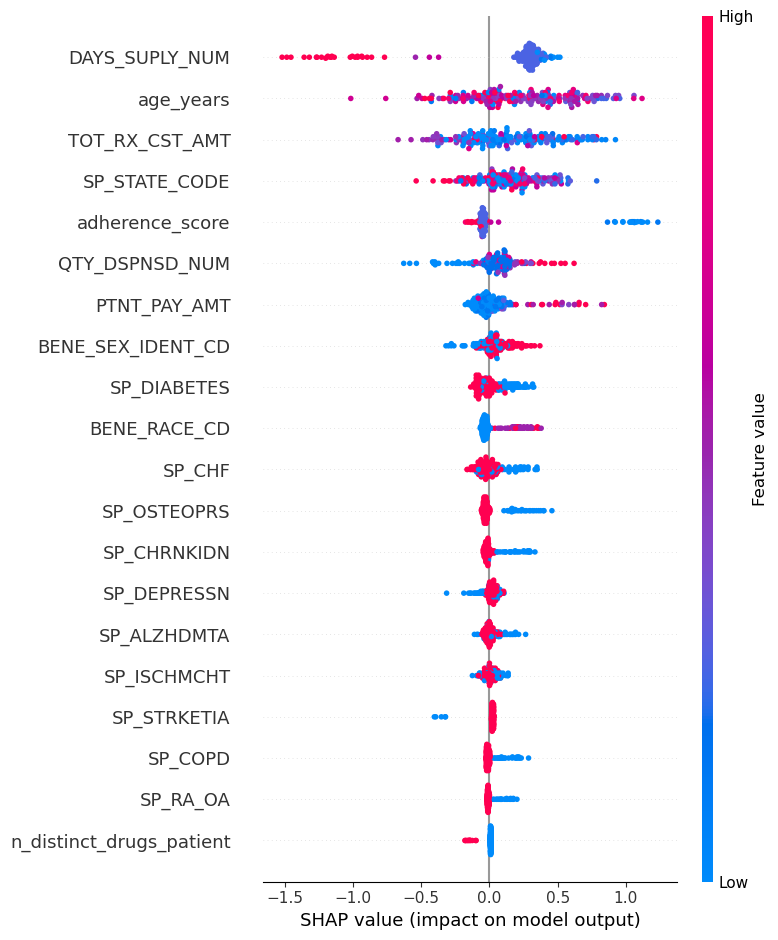

In [81]:
explainer_tuned = shap.TreeExplainer(xgb_tuned)
shap_values_tuned = explainer_tuned.shap_values(X_test)

shap.summary_plot(shap_values_tuned, X_test, max_display=20)


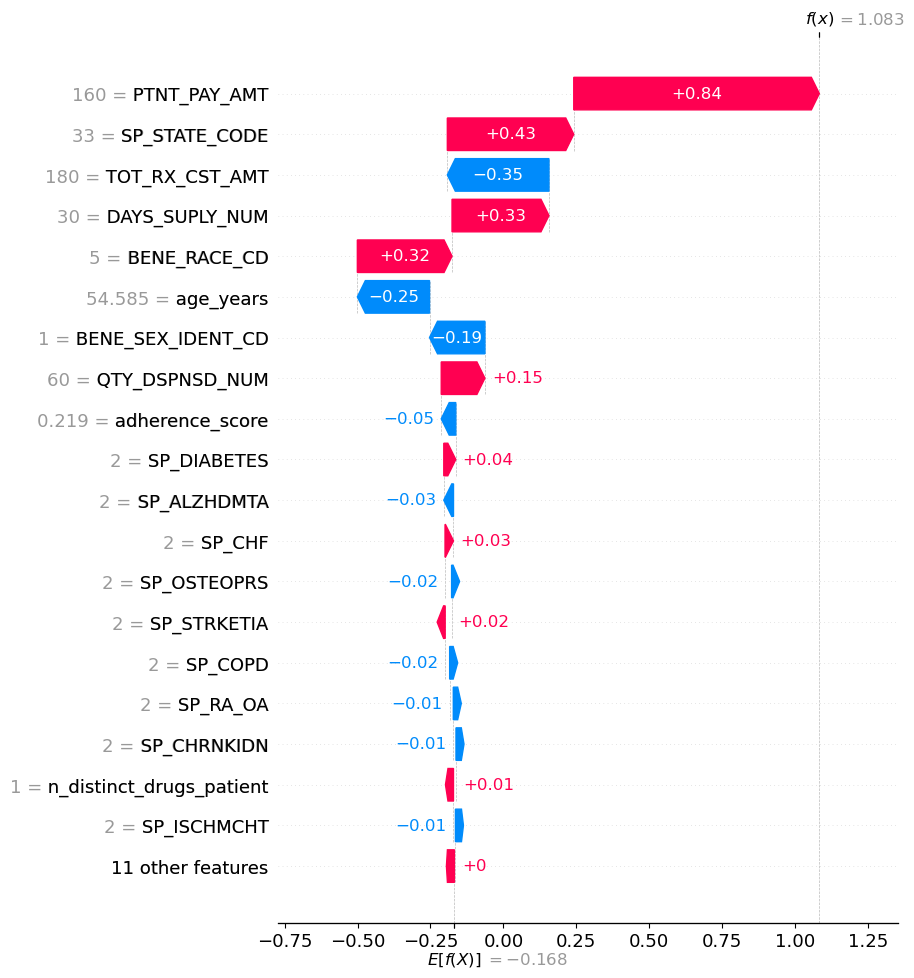

In [82]:
shap_exp_tuned = explainer_tuned(X_test)
shap.plots.waterfall(shap_exp_tuned[local_idx], max_display=20)
